<div style="border:solid green 3px; padding: 20px">
<b>🥇 Алина, спасибо за доработки, проект принят, молодец!</b>
    
Ты провела очень хорошую работу над ошибками! Уверен, ты обязательно достигнешь своей цели! Успехов в дальнейшем обучении! 🙂
    

<div style="border:solid green 2px; padding: 20px">
Алина, привет! Меня зовут Ефимов Денис и сегодня я буду делать ревью твоего проекта!
    
В Практикуме принято общаться на "ты", однако если это неудобно - дай знать, и можем перейти на более официальное общение.

Ниже ты найдешь мои комментарии - пожалуйста, не перемещай, не изменяй и не удаляй их. Я буду использовать цветовую разметку: 

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера:</b> Если все сделано хорошо. </div>

<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера:</b> Некритичное замечание, рекомендация.</div>

<div class="alert alert-block alert-danger">
<b>❌Комментарий ревьюера:</b> Грубая ошибка, необходимо исправить, иначе проект не будет принят.
</div>

Давай работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:
Например так:
<div class="alert alert-block alert-info">
<b>🔄Комментарий студента:</b> 
Hello World! ✔
</div>

Или можешь использовать эту галочку ✔ в моих комментариях, если писать особо нечего.

<div class="alert alert-block alert-warning">
<b>Общее впечатление:</b> 
    
- Ты проделала огромную работу :)
- У меня есть несколько замечаний, исправив которые ты сделаешь проект  лучше.
- Пробегись по моим комментариям, исправь недочёты и всё будет отлично :)
    
</div>



# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

## Откройте файл с данными и изучите общую информацию

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера:</b> Правильно, что импортируешь все библиотеки в отдельной ячейке!  </div>

Предварительно попробовав распечатать таблицу, я увидела, что в этой таблице данные разделены не привычными запятыми, а разделителем "/t", что отображено в коде ниже. Впоследствии таблица выводится на экран корректно.

In [2]:
data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t') #читаем таблицу

In [3]:
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [4]:
data.info() #изучим общую информацию о таблице

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

Из общей информации видно, что в таблице присустствует очень много пропусков, например, в графе 'is_apartment' заполнено меньше 10% строк, эти пропуски необходимо обработать. Также в последующем предстоит изменить тип данных у некоторых колонках, например, колонку 'first_day_exposition' лучше привести к типу datetime.

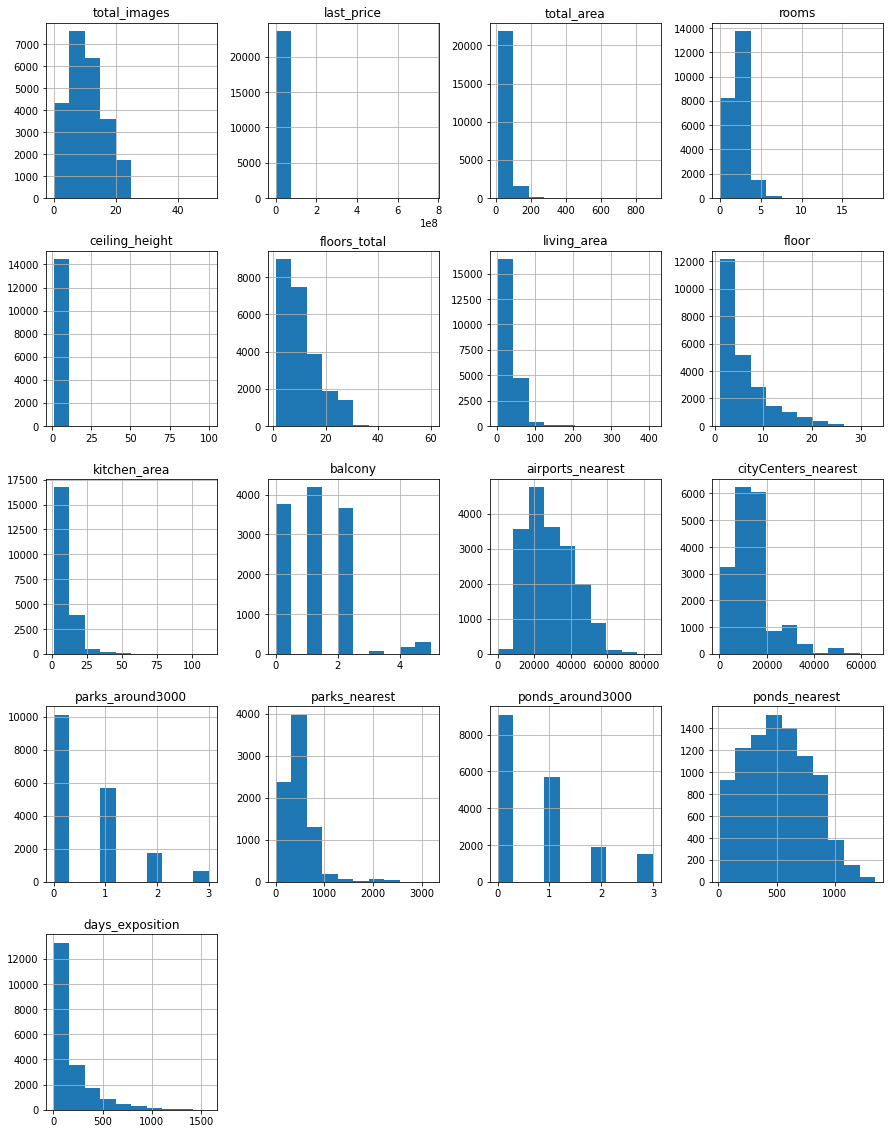

In [5]:
data.hist(figsize=(15, 20))
plt.show()

<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера:</b> 
    
Чтобы перед графиком не выводился длинный список с параметрами, можно просто добавить строку `plt.show()` после строки построения графика.  </div>


 ✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

По полученным графикам можно примерно представить размах данных, но делать анализ по ним не получится, так как данные не готовы к исследованию. Некоторые графики из-за единиц измерения или параметров совсем неинформативны, например, график по колонке 'last_price' из-за того, что цена записана в миллионах, гистограмма представляет собой столб данных, на котором не видно настоящей картины распределения.

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера:</b> Отлично, с данными познакомились!  </div>

## Выполните предобработку данных

In [6]:
data.columns 
#проверим названия столбцов

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'cityCenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest', 'days_exposition'],
      dtype='object')

In [7]:
data.rename(columns={'cityCenters_nearest': 'city_сenters_nearest'}, inplace=True)
# переименуем столбец cityCenters_nearest в стиле snake_case

### Заполнение пропусков

In [8]:
data.isna().sum() #посчитаем количество пропусков в каждом столбце

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_сenters_nearest     5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

#### Заполнение пропусков столбце 'ceiling_height'

Начнем заполнение пропусков по порядку, с колонки 'ceiling_height'. В колонке содержится численное значение, которое определяет высоту потолка в квартире. Заполнить пропуски можно либо средним, либо медианным значением. Для того, чтобы понять, какой вариант выбрать, изучим уникальные значения в этой колонке.

In [9]:
data['ceiling_height'].sort_values().unique() #выводим отсортированный массив уникальных значений в колонке
#'ceiling_height'

array([  1.  ,   1.2 ,   1.75,   2.  ,   2.2 ,   2.25,   2.3 ,   2.34,
         2.4 ,   2.45,   2.46,   2.47,   2.48,   2.49,   2.5 ,   2.51,
         2.52,   2.53,   2.54,   2.55,   2.56,   2.57,   2.58,   2.59,
         2.6 ,   2.61,   2.62,   2.63,   2.64,   2.65,   2.66,   2.67,
         2.68,   2.69,   2.7 ,   2.71,   2.72,   2.73,   2.74,   2.75,
         2.76,   2.77,   2.78,   2.79,   2.8 ,   2.81,   2.82,   2.83,
         2.84,   2.85,   2.86,   2.87,   2.88,   2.89,   2.9 ,   2.91,
         2.92,   2.93,   2.94,   2.95,   2.96,   2.97,   2.98,   2.99,
         3.  ,   3.01,   3.02,   3.03,   3.04,   3.05,   3.06,   3.07,
         3.08,   3.09,   3.1 ,   3.11,   3.12,   3.13,   3.14,   3.15,
         3.16,   3.17,   3.18,   3.2 ,   3.21,   3.22,   3.23,   3.24,
         3.25,   3.26,   3.27,   3.28,   3.29,   3.3 ,   3.31,   3.32,
         3.33,   3.34,   3.35,   3.36,   3.37,   3.38,   3.39,   3.4 ,
         3.42,   3.43,   3.44,   3.45,   3.46,   3.47,   3.48,   3.49,
      

По массиву видно, что данные содержат много выбросов, нереалистичных значений. Вряд ли есть квартиры с потолком высотой 100 или 1 метров. В наличии выбросов можно убедиться с помощью диаграммы размаха.

(0.0, 5.0)

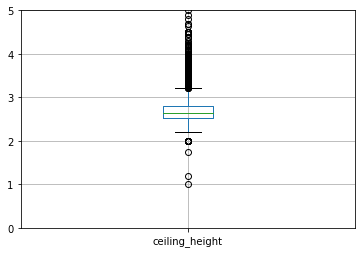

In [10]:
data.boxplot('ceiling_height')
plt.ylim(0, 5)

Действительно, на графике мы видим огромное количество выбросов, которые могут сильно исказить среднее значение высоты потолка, поэтому в данном случае надежнее будет заполнить пропуски медианным значением столбца.

In [11]:
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median()) 
#заполняем пропуски медианным значением

Пропуски в этой и других строчках, заполняемых продавцом вручную могли возникнуть из-за человеческого фактора, например, пользователь просто забыл написать высоту потолка, либо не знал ее точно.

#### Заполнение пропусков в столбце 'floors_total'

В колонке 'floors_total' всего 86 пропусков, что не так много по сравнению с пропусками в других колонках. Так же можно заметить, что колонка 'floor', которая содержит в себе этаж, на котором расположена квартира, заполнена для всех строчек и не содержит пропусков. При заполнении пропусков средним значением или медианой в колонке 'floors_total' может произойти ситуация, при которой общее количество этажей в доме будет меньше, чем этаж, на которой располагается квартира, что приведет к путанице в анализе. Поэтому мною было принято решение не заполнять пропуски в данной колонке.

Пропуски в этой колонке могли возникнуть так же по причине случайного пропуска, либо в тех случаях, когда квартира находилась на последнем этаже и пользователь не сочел важным указать общее количество этажей в доме.

#### Заполнение пропусок в столбце 'living_area' и 'kitchen_area'

Посчитаем среднее отношение жилой площади к общей площади в строках без пропусков, назовем этот коэффициент living_area_ratio

In [12]:
living_area_ratio = (data['living_area']/data['total_area']).mean()

Заполним пропуски в колонке living_area произведением total_area на living_area

In [13]:
data['living_area'] = data['living_area'].fillna(data['total_area'] * living_area_ratio)

In [14]:
data['living_area'].isna().sum() #проверим количество пропусков после заполнения

0

Аналогичным образом заполним пропуски в колонке kitchen_area

In [15]:
kitchen_area_ratio = (data['kitchen_area']/data['total_area']).mean()

In [16]:
data['kitchen_area'] = data['kitchen_area'].fillna(data['total_area'] * kitchen_area_ratio)

In [17]:
data['kitchen_area'].isna().sum() #проверим количество пропусков после заполнения

0

<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера:</b>

Такое заполнение некорректно, ведь кроме жилой площади и площади кухни в квартирах есть прихожие, ванные комнаты, санузлы, гардеробные и т.д. 



Пропуски можно заполнить так: сначала вычисляем среднее отношение жилой площади к общей, это будет наш коэффициент жилой площади. Далее в строках с пропусками умножаем общую площадь на этот коэффициент, получая жилую площадь.

Подобным образом можно заполнить пропуски и в столбце с площадью кухни.</div>

 ✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

С помощью коэффициентов отношения жилой площади к общей площади квартиры и отношения площади кухни к площади квартиры удалось полностью заполнить пропуски в колонках living_area и kitchen_area

#### Заполнение пропусков в колонке is_apartment и balcony

In [18]:
data['is_apartment'].value_counts()

False    2725
True       50
Name: is_apartment, dtype: int64

Пропусков в колонке is_apartment больше 20000 и всего 50 объявлений имеют статус "апартаменты", скорее всего пропуски в объявлениях означают, что квартира не является апартаментами и поэтому собственник решил не указывать этот параметр, в таком случае заполним все пропуски значением False.

In [19]:
data['is_apartment'] = data['is_apartment'].fillna(False)

Аналогично поступим с колонкой balcony, пропуски скорее всего возникают в тех квартирах, в которых нет балконов, поэтому заполним их 0.

In [20]:
data['balcony'] = data['balcony'].fillna(0)

<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера:</b>

Так как столбец должен быть числового типа, то и пропуски следует заполнять значением соответствующего типа. </div>

 ✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

#### Заполнение пропусков в колонкe locality_name

Взглянем на значения в колонке locality_name

In [21]:
data['locality_name'].value_counts()

Санкт-Петербург        15721
посёлок Мурино           522
посёлок Шушары           440
Всеволожск               398
Пушкин                   369
                       ...  
посёлок Шугозеро           1
поселок Дружноселье        1
поселок Гаврилово          1
посёлок Белоостров         1
деревня Реброво            1
Name: locality_name, Length: 364, dtype: int64

Метод value_counts показывает, что большинство объявлений находятся в Санкт-Петербурге, причем доля их значительно больше, чем в остальных районах, поэтому смею предположить, что пропущенные значения тоже будут находиться именно в черте города. Заполним пропуски модой.

In [22]:
data['locality_name'] = data['locality_name'].fillna(data['locality_name'].mode()[0])
# data['locality_name'].mode() является серией, поэтому чтобы взять значение, используем индекс 0

Пропуски в этой колонке могли появится из-за сбоев в приеме информации, так как локация все-таки важный пункт при продаже жилья, вряд ли пользователь просто забыл его указать, либо он понадеялся на автоматическое определение геолокации, которое его подвело.

#### Заполнение пропусков в колонках parks_nearest и ponds_nearest

<div class="alert alert-block alert-danger">
<b>❌Комментарий ревьюера:</b> 
    
Обрати внимание на то, что эти значения  получены автоматически на основе картографических данных. А если данные не получены, то скорее всего объекта рядом нет (пруды и парки) или до объекта слишком далеко и эту информацию нельзя получить (а значит она и не будет иметь значения при исследовании)
    
А заполняя пропуски медианой, мы переносим квартиры и сажаем рядом парки и выкапываем пруды)) Это неправильно. Лучше в таком случае оставить пропуски как есть.

</div>

 ✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

В колонках airports_nearest, city_centers_nearest, parks_around3000, ponds_around3000, которые заполняются автоматические, практически одинаковое количество пропусков, проверим, находятся пропуски в одних и тех же строчках или нет. 

In [23]:
data.loc[:,'airports_nearest':'ponds_nearest'].isna().all(axis=1).sum()
# в срез добавим так же колонки parks_nearest и ponds_nearest

5518

Что и требовалось доказать, 5518 строчек имеют пропуски в одних и тех же столбцах, возможно проблема в расположении этих квартир и невозможности определить эти данные автоматически, изучим значения locality_name для этих строчек.

In [24]:
data[data.loc[:,'airports_nearest':'ponds_nearest'].isna().all(axis=1)].loc[:, 'locality_name'].unique()

array(['городской посёлок Янино-1', 'посёлок Мурино', 'Сертолово',
       'деревня Кудрово', 'Коммунар',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кировск',
       'деревня Новое Девяткино', 'Санкт-Петербург',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'деревня Пикколово',
       'Всеволожск', 'Волхов', 'Кингисепп', 'Приозерск',
       'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Сясьстрой', 'деревня Старая', 'деревня Лесколово',
       'посёлок Новый Свет', 'Сланцы', 'село Путилово', 'Ивангород',
       'Мурино', 'Шлиссельбург', 'Никольское', 'Сосновый Бор',
       'поселок Новый Свет', 'деревня Оржицы', 'деревня Кальтино',
 

In [25]:
(data[
    (data.loc[:,'airports_nearest':'ponds_nearest'].isna().all(axis=1))
    & 
    (data['locality_name'] == "Санкт-Петербург")]
     ['locality_name']
     .count()) #считаем количество строк, у которых пропуски в столбцах 
# airports_nearest, cityCenters_nearest, parks_around3000, parks_nearest, ponds_around3000, ponds_nearest,
# а в столбце locality_name - Санкт-Петербург

69

Большая часть таких объявлений находится в селах и деревнях, возможно геосервисам не удается определить расстояние до аэропорта или центра города, потому что оно слишком большое, а парков и прудов в доступе нет. Но тем не менее в объявлениях, находящихся в Санкт-Петербурге тоже присутствуют пропуски в рассматриваемых колонках. Как бы там ни было, даже большое расстояние может быть определено в этих колонках, я считаю, что причина пропусков в сбоях работы геосервисов и отправила бы эти данные на пересмотр.
В дальнейших расчетах я буду игнорировать пропуски данных в этих колонках.

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера:</b> 

Здесь все верно!</div>

#### Заполнение пропусков в колонке days_exposition

Проверим, сколько в среднем дней занимает продажа квартиры

In [26]:
data['days_exposition'].mean() # считаем среднее арифметическое

180.88863436982163

In [27]:
data['days_exposition'].median() # считаем медиану

95.0

Медиана показывает, что, как минимум, половина квартир продавалась быстрее, чем за 95 дней, но даже если смотреть на среднее, которое подвержено влиянию выбросов, продажа в среднем составляла полгода.
Проверим, когда были выложены объявления, в которых имеются пропуски в колонке days_exposition

In [28]:
data[data['days_exposition'].isna()]['first_day_exposition'].sort_values().unique()

array(['2014-11-27T00:00:00', '2014-12-08T00:00:00',
       '2014-12-09T00:00:00', '2014-12-10T00:00:00',
       '2014-12-11T00:00:00', '2014-12-12T00:00:00',
       '2014-12-27T00:00:00', '2015-01-03T00:00:00',
       '2015-01-15T00:00:00', '2015-01-20T00:00:00',
       '2015-01-21T00:00:00', '2015-01-22T00:00:00',
       '2015-01-23T00:00:00', '2015-01-27T00:00:00',
       '2015-02-11T00:00:00', '2015-02-12T00:00:00',
       '2015-02-19T00:00:00', '2015-02-28T00:00:00',
       '2015-03-10T00:00:00', '2015-03-11T00:00:00',
       '2015-03-13T00:00:00', '2015-03-23T00:00:00',
       '2015-03-25T00:00:00', '2015-03-26T00:00:00',
       '2015-04-13T00:00:00', '2015-04-22T00:00:00',
       '2015-05-08T00:00:00', '2015-05-09T00:00:00',
       '2015-05-20T00:00:00', '2015-06-02T00:00:00',
       '2015-06-03T00:00:00', '2015-06-17T00:00:00',
       '2015-06-18T00:00:00', '2015-06-23T00:00:00',
       '2015-06-25T00:00:00', '2015-06-30T00:00:00',
       '2015-08-06T00:00:00', '2015-08-10T00:0

Видно, что есть объявления еще с 2014 года, то есть 5-летней давности (считая от последней даты в таблице), если бы все обявления были более "молодыми" можно было бы утверждать, что эти квартиры просто еще не проданы. Давайте взглянем на максимальное значение в колонке days_exposition, чтобы узнать, есть ли вообще такие случаи, когда квартира не продавалась больше 5-ти лет в данных.

In [29]:
data['days_exposition'].max()

1580.0

Это значение меньше, чем разница между первой датой в списке уникальных значений с пропусками в колонке days_exposition, поэтому нельзя сказать точно, что все объявления с пропусками еще не продались, но и заполнить их все медианой тоже не кажется правильным. Поэтому я приняла решение оставить пропуски в этой колонке незаполненными, возможно причина пропусков в сбоях на сайте, либо объявления не были сняты с публикации после продажи.

In [30]:
data.isna().sum()
 #проверим количество оставшихся пропусков

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total               86
living_area                 0
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area                0
balcony                     0
locality_name               0
airports_nearest         5542
city_сenters_nearest     5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

### Преобразование типов данных

In [31]:
data.info() #изучим типы данных имеющихся данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        23699 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           23699 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          23699 non-null  bool   
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          23699 non-null  float64
 13  balcony               23699 non-null  float64
 14  locality_name         23699 non-null  object 
 15  airports_nearest   

Изменим тип данных в колонке first_day_exposition на datetime для того, чтобы было удобнее работать с датами, была возможно извлекать месяц, год, день и тд.
А также в колонке balcony тип данных можно заменить на int, так как количество балконов может быть только целым числом. 

In [32]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
#меняем тип данных в колонке fisrt_day_exposition

In [33]:
data['balcony'] = data['balcony'].astype('int')
#меняем тип данных в колонке balcony

In [34]:
data.info() #проверяем преобразование типа данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        23699 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           23699 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  bool          
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          23699 non-null  float64       
 13  balcony         

### Работа с дубликатами

In [35]:
data.duplicated().sum() #проверим наличие явных дубликатов 

0

Убедились, что повторяющихся строчек в таблице нет, перейдем к исследованию неявных дубликатов в столбце locality_name 

In [36]:
data['locality_name'].sort_values().unique() #выведем на экран уникальные значения столбца locality_name

array(['Бокситогорск', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Высоцк', 'Гатчина', 'Зеленогорск', 'Ивангород', 'Каменногорск',
       'Кингисепп', 'Кириши', 'Кировск', 'Колпино', 'Коммунар',
       'Красное Село', 'Кронштадт', 'Кудрово', 'Лодейное Поле',
       'Ломоносов', 'Луга', 'Любань', 'Мурино', 'Никольское',
       'Новая Ладога', 'Отрадное', 'Павловск', 'Петергоф', 'Пикалёво',
       'Подпорожье', 'Приморск', 'Приозерск', 'Пушкин', 'Санкт-Петербург',
       'Светогорск', 'Сертолово', 'Сестрорецк', 'Сланцы', 'Сосновый Бор',
       'Сясьстрой', 'Тихвин', 'Тосно', 'Шлиссельбург',
       'городской поселок Большая Ижора', 'городской поселок Янино-1',
       'городской посёлок Будогощь', 'городской посёлок Виллози',
       'городской посёлок Лесогорский', 'городской посёлок Мга',
       'городской посёлок Назия', 'городской посёлок Новоселье',
       'городской посёлок Павлово', 'городской посёлок Рощино',
       'городской посёлок Свирьстрой', 'городской посёлок Совет

Найдем количество уникальных значений в колонке locality_name, чтобы в последующем отследить работу над неявными дубликатами

In [37]:
data['locality_name'].nunique()

364

<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера:</b> 
    
Количество уникальных значений в столбце можно узнать с помощью метода `nunique()`  </div>


 ✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

In [38]:
data['locality_name'] = data['locality_name'].str.replace('ё', 'е')
# заменим букву ё на е, чтобы избавиться от дубликатов по типу 'посёлок' - 'поселок' 

In [39]:
locality_types = ['поселок городского типа имени ', 
                  'поселок городского типа ', 
                  'городской поселок ', 
                  'поселок станции ', 
                  'поселок при железнодорожной станции ', 
                  'деревня ', 
                  'коттеджный поселок ', 
                  'поселок станции ', 
                  'посeлок городского типа ', 
                  'садоводческое некоммерческое товарищество ', 
                  'садовое товарищество ', 
                  'село ', 
                  'поселок '] 
# с помощью цикла, избавимся от наименований типа локаций, чтобы остались только названия 
for locality_type in locality_types:
    data['locality_name'] = (
        data['locality_name']
        .str.replace(locality_type, '')
    ) 

In [40]:
data['locality_name'].sort_values().unique() #выведем новый список названий локаций без типа локации

array(['Агалатово', 'Александровская', 'Алексеевка', 'Аннино', 'Аро',
       'Барышево', 'Батово', 'Бегуницы', 'Белогорка', 'Белоостров',
       'Бокситогорск', 'Большая Вруда', 'Большая Ижора',
       'Большая Пустомержа', 'Большие Колпаны', 'Большое Рейзино',
       'Большой Сабск', 'Бор', 'Борисова Грива', 'Бугры', 'Будогощь',
       'Ваганово', 'Важины', 'Вартемяги', 'Вахнова Кара', 'Вещево',
       'Виллози', 'Вознесенье', 'Возрождение', 'Войсковицы', 'Войскорово',
       'Володарское', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Вырица', 'Выскатка', 'Высокоключевой', 'Высоцк', 'Гаврилово',
       'Гарболово', 'Гатчина', 'Гладкое', 'Глажево', 'Глебычево',
       'Глинка', 'Гончарово', 'Горбунки', 'Гостилицы', 'Громово',
       'Дзержинского', 'Дружная Горка', 'Дружноселье', 'Дубровка',
       'Елизаветино', 'Ефимовский', 'Жилгородок', 'Жилпоселок', 'Житково',
       'Заводской', 'Заклинье', 'Заневка', 'Запорожское', 'Зеленогорск',
       'Зимитицы', 'Ивангород', 'Извара'

In [41]:
data['locality_name'].nunique()

305

**Вывод:** мы избавились от 59 неявных дуликатов

## Добавьте в таблицу новые столбцы

In [42]:
data['price_per_meter'] = round(data['last_price'] / data['total_area'], 2)
# добавляем цену за 1 квадратный метр

In [43]:
data['weekday_of_exposition'] = data['first_day_exposition'].dt.weekday
# добавляем колонку с днем недели публикации

In [44]:
data['month_of_exposition'] = data['first_day_exposition'].dt.month
# добавляем колонку с номером месяца публикации

In [45]:
data['year_of_exposition'] = data['first_day_exposition'].dt.year
# добавляем колонку с годом публикации

In [46]:
data['floor_type'] = 'другой'
data.loc[data['floor'] == 1, 'floor_type'] = 'первый'
data.loc[data['floor'] == data['floors_total'], 'floor_type'] = 'последний'
# добавляем колонку с типом этажа

In [47]:
data['city_centers_nearest_km'] = round(data['city_сenters_nearest']/1000)
# добавляем колонку с расстоянием до центра в километрах

In [48]:
data.head() # проверим новые колонки

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_meter,weekday_of_exposition,month_of_exposition,year_of_exposition,floor_type,city_centers_nearest_km
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.000000,8,False,...,482.0,2.0,755.0,NaN,120370.37,3,3,2019,другой,16.0
1,7,3350000.0,40.4,2018-12-04,1,2.65,11.0,18.600000,1,False,...,NaN,0.0,NaN,81.0,82920.79,1,12,2018,первый,19.0
2,10,5196000.0,56.0,2015-08-20,2,2.65,5.0,34.300000,4,False,...,90.0,2.0,574.0,558.0,92785.71,3,8,2015,другой,14.0
3,0,64900000.0,159.0,2015-07-24,3,2.65,14.0,89.797718,9,False,...,84.0,3.0,234.0,424.0,408176.10,4,7,2015,другой,7.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.000000,13,False,...,112.0,1.0,48.0,121.0,100000.00,1,6,2018,другой,8.0


<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера:</b> Дополнительные данные рассчитаны и добавлены верно! Можно приступать к исследованию🙂 </div>

<div class="alert alert-block alert-danger">
<b>❌Комментарий ревьюера:</b> 
    
После этапа предобработки также нужно сделать краткий резюмирующий вывод о проделанной работе.</div>


 ✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

**Вывод:** В ходе предобработки данных:

   - мне удалось найти логичную замену для некоторых пропусков(is_apartment, balcony, ceiling_height, living_area, kitchen_area, locality_name)
   - часть пропусков в столбцах, значения которых определяются автоматически, не удалось заполнить логической заменой, так как заполнения их могли исказить реальную картину (столбцы city_centers_nearest, parks_around3000, parks_nearest, parks_around_3000, airports_nearest, days_exposition)
   - я поменяла тип данных в колонке first_day_exposition, balcony на datetime и int соответственно
   - удалила 59 неявных дубликатов в колонке locality_name
   - добавила новые столбцы price_per_meter, weekday_of_exposition, month_of_exposition, year_of_exposition, floor_type, city_centers_nearest_km
   

## Проведите исследовательский анализ данных

### Исследование гистограмм распределения параметров

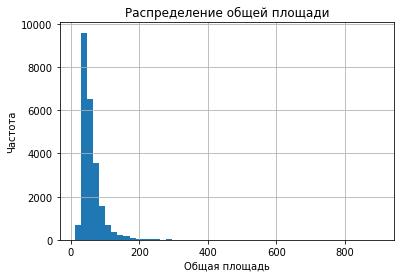

In [49]:
data['total_area'].hist(bins=50) 
plt.xlabel('Общая площадь')  
plt.ylabel('Частота')  
plt.title('Распределение общей площади')
plt.show()
#построим гистограмму распределения общей площади квартиры, для точности возьмем количество корзин равное 50

По гистограмме видно, что большая часть значений лежит в промежутке от 0 до 200, есть и большие значения, которые уходят вплоть до 900 кв м, но они либо не является квартирами, либо являются выбросами, поэтому для более точного результата ограничим значения от 0 до 200.

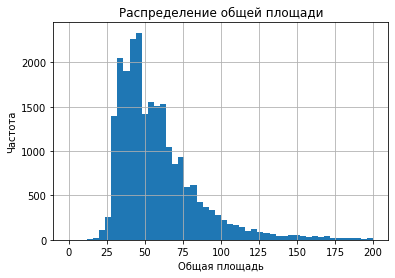

In [50]:
data['total_area'].hist(range=(0, 200), bins=50)
plt.xlabel('Общая площадь')  
plt.ylabel('Частота')  
plt.title('Распределение общей площади')
plt.show()
# построим гистограмму распределения общей площади квартиры, для точности возьмем количество корзин равное 50
# и ограничим значения от 0 до 200, чтобы исключить слишком большие значения

In [51]:
data['total_area'].describe() # изучим статистику по колонке total_area с помощью метода describe

count    23699.000000
mean        60.348651
std         35.654083
min         12.000000
25%         40.000000
50%         52.000000
75%         69.900000
max        900.000000
Name: total_area, dtype: float64

<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера:</b>

В качестве дополнительного инструмента для анализа можно использовать `describe()`</div>


 ✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

75% значений находятся до 70 кв метров, межквартильный размах равен 28,9.
Можем вычислить значения левого и правого "усов" :
Q1 - 1,5*IQR = 40 - 43,35 - значение площади не может быть отрицательным, поэтому будем брать значения, начиная с 0 
Q3 + 1,5*IQR = 68,9 + 43,35 = 112,25

Округлим значение правого "уса" до 115 кв метров

In [52]:
data = data.query('total_area < 115') # обрезаем лишние данные

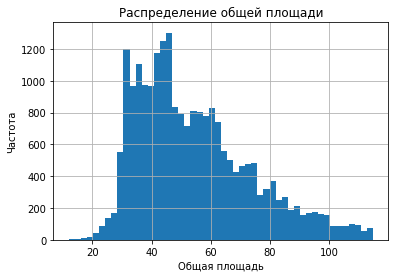

In [53]:
data['total_area'].hist(bins=50)
plt.xlabel('Общая площадь')  
plt.ylabel('Частота')  
plt.title('Распределение общей площади')
plt.show()#строим еще раз гистограмму

Гистограмма распределения общей площади квартиры несимметричная, большая часть значений расположена слева (до 60кв м) и достигает своего пика между 25 и 50 кв метрами.


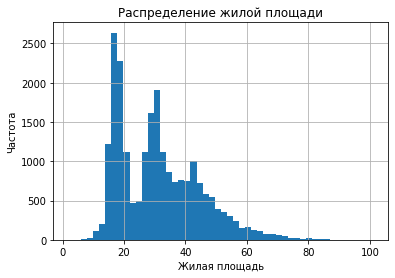

In [54]:
data['living_area'].hist(bins=50)
plt.xlabel('Жилая площадь')  
plt.ylabel('Частота')  
plt.title('Распределение жилой площади')
plt.show()
#построим гистограмму распределения жилой площади квартиры 

In [55]:
data['living_area'].describe() # опишем колонку living_area с помощью метода describe()

count    22462.000000
mean        31.060303
std         13.346131
min          2.000000
25%         18.600000
50%         29.700000
75%         40.000000
max        101.000000
Name: living_area, dtype: float64

75% жилой площади находится до 40 кв метров, межквартильный размах равен 22 кв метра
Можем вычислить значения левого и правого "усов" :
Q1 - 1,5*IQR = 18 - 33 - значение площади не может быть отрицательным, поэтому будем брать значения, начиная с 0 
Q3 + 1,5*IQR = 40 + 33 = 73

Округлим значение правого "уса" до 75 кв метров

In [56]:
data = data.query('living_area < 75') # обрезаем лишние данные

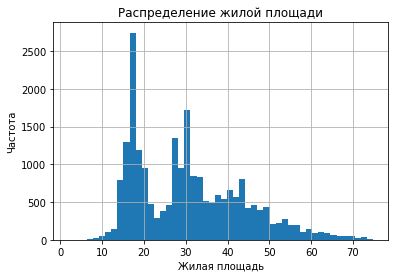

In [57]:
data['living_area'].hist(bins=50)
plt.xlabel('Жилая площадь')  
plt.ylabel('Частота')  
plt.title('Распределение жилой площади')
plt.show()# еще раз проверяем гистограмму living_area

Несимметричность гистограммы сохраняется, основная доля имеет жилую площадь до 40 кв метров. Мы видим 2 пика: в районе 15-20 кв метров и в районе 30 кв метров. Наблюдается резкий спад квартир с жилой площадью, равеной 22-23 кв метра. Это коррелируется с распределением общей площади жилья и может быть связано с типовыми планировками квартир. 

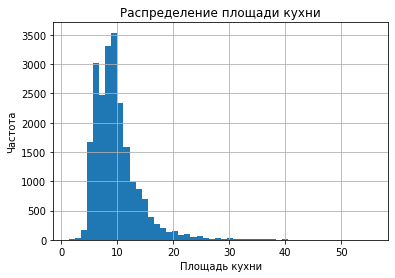

In [58]:
data['kitchen_area'].hist(bins=50)
plt.xlabel('Площадь кухни')  
plt.ylabel('Частота')  
plt.title('Распределение площади кухни')
plt.show()
# построим гистограмму распределения площади кухни

In [59]:
data['kitchen_area'].describe() # опишем колонку kitchen_area с помощью метода describe()

count    22370.000000
mean         9.833272
std          4.292501
min          1.300000
25%          7.000000
50%          9.000000
75%         11.300000
max         55.700000
Name: kitchen_area, dtype: float64

75% площади кухни находится до 11.3 кв метров, межквартильный размах равен 4.3 кв метра
Можем вычислить значения левого и правого "усов" :
Q1 - 1,5*IQR = 7 - 6,45 = 0,55 (для простоты возьмем значения, начиная с 0)
Q3 + 1,5*IQR = 11,3 + 6,45 = 17,75

Округлим значение правого "уса" до 20 кв метров

In [60]:
data = data.query('kitchen_area < 20') # обрезаем лишние данные

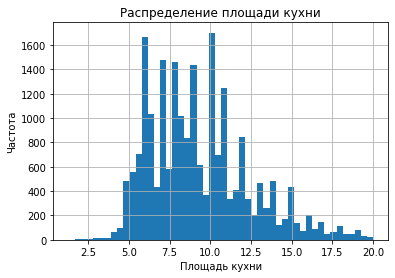

In [61]:
data['kitchen_area'].hist(bins=50)
plt.xlabel('Площадь кухни')  
plt.ylabel('Частота')  
plt.title('Распределение площади кухни') 
plt.show()# построим еще раз гистограмму kitchen_area

Гистограмма получилась очень "шероховатой" и имеет много пиков и, наоборот, "ям". По этой гистограмме видно, что кухни определенных размеров встречаются чаще остальных, это так же может быть связано с типовыми планировками квартир

Text(0.5, 1.0, 'Распределение стоимости квартиры')

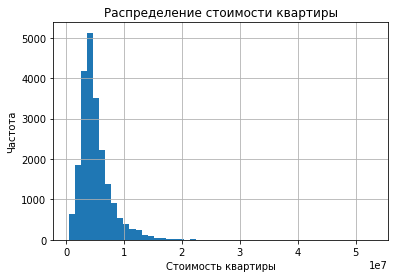

In [62]:
data['last_price'].hist(bins=50)
plt.xlabel('Стоимость квартиры')  
plt.ylabel('Частота')  
plt.title('Распределение стоимости квартиры') 

На такой гистограмме ничего непонятно, так как слишком большой размах цены, большая часть значений находится до 10000000

In [63]:
data['last_price'].describe() # опишем колонку last_price с помощью метода describe()

count    2.170200e+04
mean     5.094496e+06
std      2.993985e+06
min      4.300000e+05
25%      3.300000e+06
50%      4.444260e+06
75%      6.090525e+06
max      5.300000e+07
Name: last_price, dtype: float64

75% квартир имеют стоимость до 6,1 млн, межквартильный размах равен 2,8 млн
Можем вычислить значения левого и правого "усов" :
Q1 - 1,5*IQR = 3,3 - 4,2  - цена не может быть меньше 0, поэтому левую границу возьмем равную 0
Q3 + 1,5*IQR = 6,1 + 4,2 = 10,3 млн



In [64]:
data = data.query('last_price < 10300000')
# убираем лишние данные

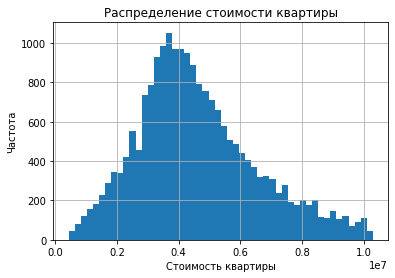

In [65]:
data['last_price'].hist(bins=50)
plt.xlabel('Стоимость квартиры')  
plt.ylabel('Частота')  
plt.title('Распределение стоимости квартиры')  
plt.show()
# строим гистограмму с новыми данными

Распределение цены скошено вправо, большинство квартир сосредоточено в ценовом диапазоне 3-5 млн

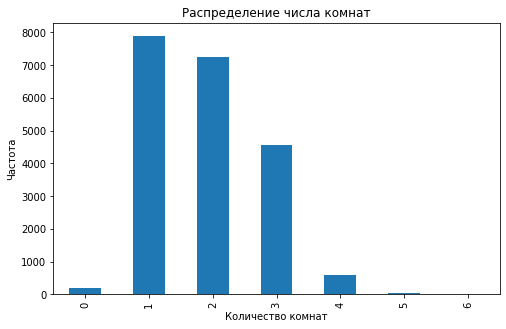

In [66]:
counts = data['rooms'].value_counts().sort_index()  
counts.plot(kind='bar', figsize=(8,5))  
plt.xlabel('Количество комнат')  
plt.ylabel('Частота')  
plt.title('Распределение числа комнат')  
plt.show()

<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера:</b> 
    
Для дискретных переменных лучше использовать барплот</div>

✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

In [67]:
data['rooms'].sort_values().unique()
# изучим уникальные значения в колонке rooms

array([0, 1, 2, 3, 4, 5, 6])

Значение "0" смущает, однако оно может означать тип квартиры - студия. Изучим эти строки

In [68]:
data.query('rooms == 0')['total_area'].median()
#изучим медианную площадь квартир с количеством комнат 0

26.0

Площадь 26 кв метров вполне себе похоже на студию, так что с этими данными все нормально, их оставляем

По гистограмме видно, что больше всего квартир с 1-й и 2-мя комнатами

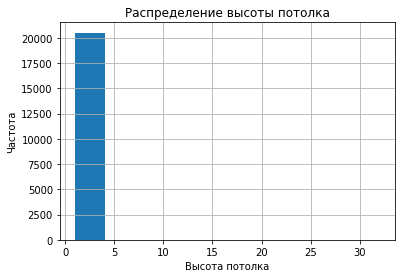

In [69]:
data['ceiling_height'].hist()
plt.xlabel('Высота потолка')  
plt.ylabel('Частота')  
plt.title('Распределение высоты потолка')  
plt.show()
# построим гистограмму распределения высоты потолков в квартирах

In [70]:
data['ceiling_height'].sort_values().unique()

array([ 1.  ,  1.2 ,  1.75,  2.  ,  2.2 ,  2.25,  2.3 ,  2.34,  2.4 ,
        2.45,  2.46,  2.47,  2.48,  2.49,  2.5 ,  2.51,  2.52,  2.53,
        2.54,  2.55,  2.56,  2.57,  2.58,  2.59,  2.6 ,  2.61,  2.62,
        2.63,  2.64,  2.65,  2.66,  2.67,  2.68,  2.69,  2.7 ,  2.71,
        2.72,  2.73,  2.74,  2.75,  2.76,  2.77,  2.78,  2.79,  2.8 ,
        2.81,  2.82,  2.83,  2.84,  2.85,  2.86,  2.87,  2.88,  2.89,
        2.9 ,  2.91,  2.92,  2.93,  2.94,  2.95,  2.96,  2.97,  2.99,
        3.  ,  3.01,  3.02,  3.03,  3.04,  3.05,  3.06,  3.07,  3.08,
        3.09,  3.1 ,  3.11,  3.12,  3.13,  3.14,  3.15,  3.16,  3.17,
        3.18,  3.2 ,  3.21,  3.22,  3.23,  3.24,  3.25,  3.26,  3.27,
        3.28,  3.3 ,  3.31,  3.32,  3.33,  3.34,  3.35,  3.36,  3.37,
        3.38,  3.4 ,  3.42,  3.44,  3.45,  3.46,  3.47,  3.48,  3.49,
        3.5 ,  3.54,  3.55,  3.56,  3.57,  3.59,  3.6 ,  3.62,  3.63,
        3.65,  3.66,  3.67,  3.7 ,  3.75,  3.78,  3.8 ,  3.83,  3.85,
        3.88,  3.9 ,

Минимально допустимая норма высоты потолков в России - 2,4 м. Максимально возможная вряд ли будет превышать 5 метров. Избавимся от лишних выбросов, но перед этим можно исправить высоты потолков 24, 25, 26, 27, 27.5, 32 метра, так как в этих значениях скорее всего просто перепутан знак

In [71]:
data.loc[data['ceiling_height'] > 10.3, 'ceiling_height'] /= 10
# заменим аномальные значения

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера:</b> 

Поделить на 10 можно немного проще:</div>


```python


                df.loc[df['ceiling_height'] > 10.3, 'ceiling_height'] /= 10

```

In [72]:
data = data.query('2.4 <= ceiling_height <= 5') 
# избавимся от выбросов

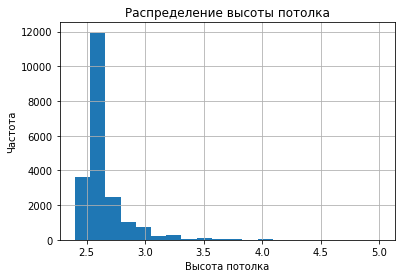

In [73]:
data['ceiling_height'].hist(bins=20)
plt.xlabel('Высота потолка')  
plt.ylabel('Частота')  
plt.title('Распределение высоты потолка')  
plt.show()

По гистограмме видно, что самая распространенная высота потолков - 2.7 метра

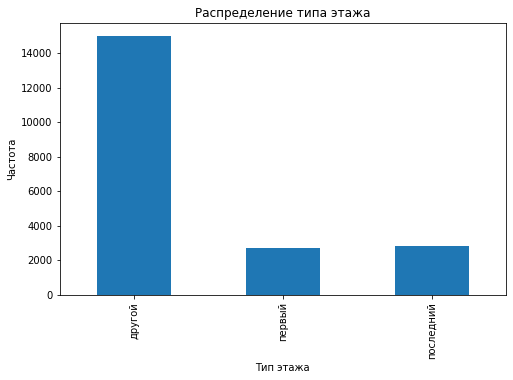

In [74]:
counts = data['floor_type'].value_counts().sort_index()  
counts.plot(kind='bar', figsize=(8,5))  
plt.xlabel('Тип этажа')  
plt.ylabel('Частота')  
plt.title('Распределение типа этажа')  
plt.show()
# построим гистограмму распределения типов этажа, bins возьмем равное 3, так как всего есть 3 типа этажей

Из гистограммы видно, что больше всего квартир находятся ни на последнем, ни на первом этажах, меньше всего - на первом.

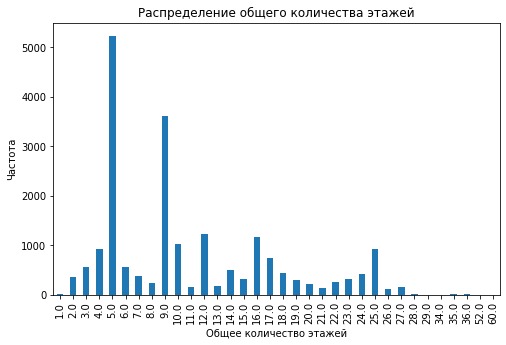

In [75]:
counts = data['floors_total'].value_counts().sort_index()  
counts.plot(kind='bar', figsize=(8,5))  
plt.xlabel('Общее количество этажей')  
plt.ylabel('Частота')  
plt.title('Распределение общего количества этажей')  
plt.show()
# построим гистограмму распределния общего количества этажей в доме

In [76]:
data['floors_total'].sort_values().unique()
# посмотрим на уникальные значения в колонке floors_total

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 34., 35., 36., 52., 60., nan])

Больше всего квартир продается в 5-этажных и 9-этажных домах

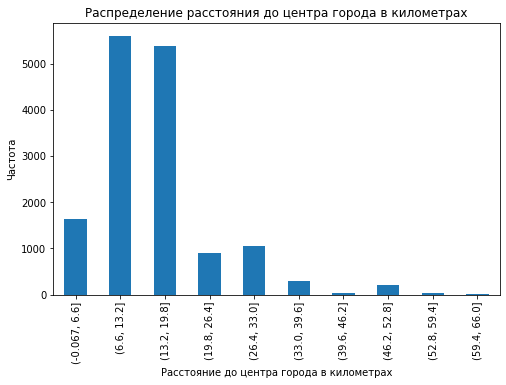

In [77]:
counts = data['city_centers_nearest_km'].value_counts(bins=10).sort_index()  
counts.plot(kind='bar', figsize=(8,5)) 
plt.xlabel('Расстояние до центра города в километрах')  
plt.ylabel('Частота')  
plt.title('Распределение расстояния до центра города в километрах')  
plt.show()
# построим столбчатую диаграмму для распределения расстояния до центра города в километрах, разделив 

Данные вполне кажутся реалистичными на гистограмме, объявления могут находиться как в центре города, так и за его пределами, в деревне или поселке, поэтому расстояние может достигать и 60-70 км. Большая часть объявлений находится в пределах от 7 до 20 км от центра города.

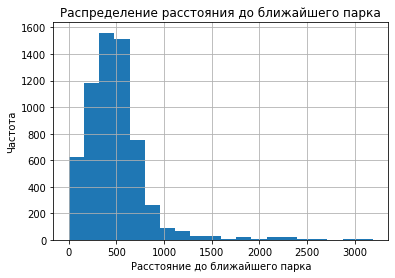

In [78]:
data['parks_nearest'].hist(bins=20) 
plt.xlabel('Расстояние до ближайшего парка')  
plt.ylabel('Частота')  
plt.title('Распределение расстояния до ближайшего парка')  
plt.show()
# построим гистограмму распределения расстояния до ближайшего парка

Гистограмма выглядит довольно реалистично, некоторые дома действительно могут располагаться прямо вблизи парков, но расстояние до них может так же превышать и 3 км. Большая часть домов находится в 400-600 метрах от парка. 

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера:</b> 

Здорово, все основные показатели квартир из объявлений изучены!</div>

### Исследование days_exposition

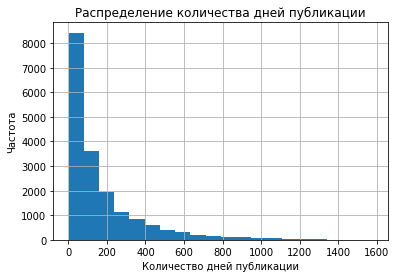

In [79]:
data['days_exposition'].hist(bins=20)
plt.xlabel('Количество дней публикации')  
plt.ylabel('Частота')  
plt.title('Распределение количества дней публикации')  
plt.show()
# построим гистограмму распределения days_exposition

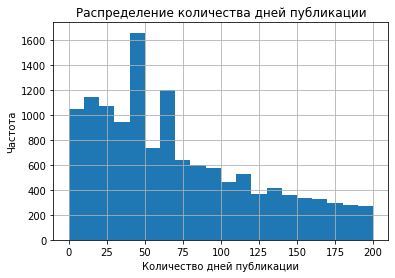

In [80]:
data['days_exposition'].hist(range=(0, 200), bins=20)
plt.xlabel('Количество дней публикации')  
plt.ylabel('Частота')  
plt.title('Распределение количества дней публикации')  
plt.show()
# рассмотрим диапазон от 0 до 200 дней поближе

<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера 2:</b>

Как ты думаешь, чем можно объяснить пики на распределении? </div>


<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера:</b>

Диапазон до 200 дней стоит рассмотреть поближе.</div>

✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

In [81]:
data['days_exposition'].mean()
# посчитаем среднее количество дней продажи квартир

169.68055325034578

In [82]:
data['days_exposition'].median()
# посчитаем медиану количества дней продажи квартир

90.00000000000001

In [83]:
data['days_exposition'].describe()
# опишем колонку days_exposition методом describe

count    18075.000000
mean       169.680553
std        207.046701
min          1.000000
25%         43.000000
50%         90.000000
75%        216.000000
max       1580.000000
Name: days_exposition, dtype: float64

Медиана более устойчива к выбросам, а значит можно считать, что в среднем на продажу квартиры уходит 90 дней. Все, что меньше 43 дней (1 квартиль) - можно считать быстрыми продажами. Все, что дольше 216 дней (3 квартиль) - можно считать долгими продажами

<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера:</b>

При ответе на вопрос о быстрых и долгих продажах лучше обратить внимание на 25 и 75 квартили. </div>

 ✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

### Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта

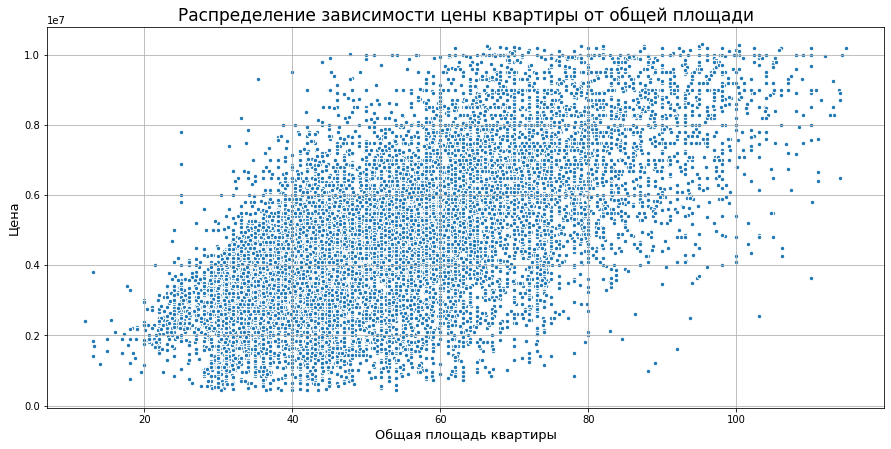

In [84]:
(data
    .plot(
        kind='scatter', 
        x='total_area', 
        y='last_price', 
        grid=True, 
        figsize=(15, 7), 
        style='o', 
        edgecolors='white')
)

plt.title('Распределение зависимости цены квартиры от общей площади', size=17)
plt.xlabel('Общая площадь квартиры', size=13)
plt.ylabel('Цена', size=13)

plt.show()
# строим график зависимости стоимости квартиры от ее общей площади

<div class="alert alert-block alert-danger">
<b>❌Комментарий ревьюера:</b> 

Для построения распределений с помощью `scatterplot` не нужно предварительное формирование сводной таблицы, иначе теряется смысл визуализации. Она должна строиться по всему массиву значений.


Есть [отличная статья](https://habr.com/ru/post/468295/), которая познакомит тебя поближе с разновидностями визуализаций

P.S. Напомню, что каждый график в проекте и оси на нем должны быть подписаны</div>


 ✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

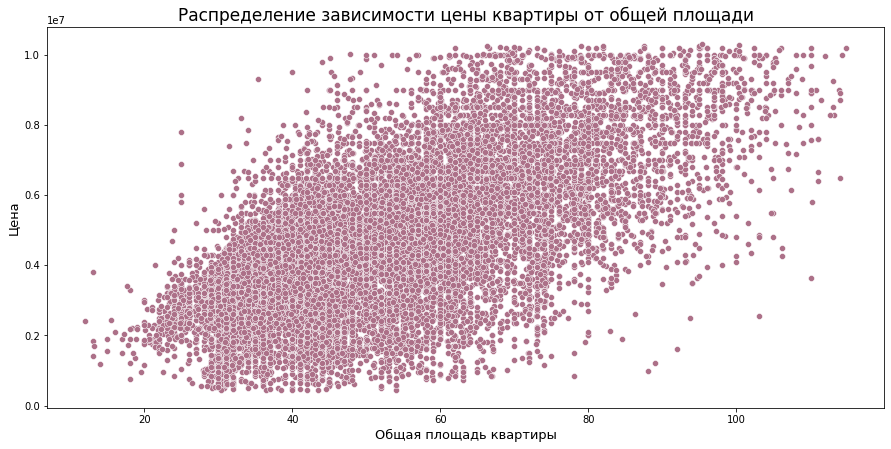

In [85]:
# код ревьюера

import seaborn as sns

plt.figure(figsize=(15, 7))

sns.scatterplot(data=data,  x='total_area', y='last_price', color='#AC7088')

plt.title('Распределение зависимости цены квартиры от общей площади', size=17)
plt.xlabel('Общая площадь квартиры', size=13)
plt.ylabel('Цена', size=13)

plt.show()

По графику видно, что с увеличением площади квартиры растет и цена, однако график достаточно 'шершавый', но это можно объяснить тем, что мы анализируем не только квартиры в пределах Санкт-Петербурга, где можно найти люксовые варианты за высокую стоимость, но и квартиры в деревнях и поселках, где цена за тот же метраж значительно ниже

In [86]:
data['last_price'].corr(data['total_area']) # проверим корреляцию

0.6630263786962827

Коэффициент корреляции достаточно высокий (>0.5), связь определенно есть и она прямопропорциональная, как я и предположила из графика. 

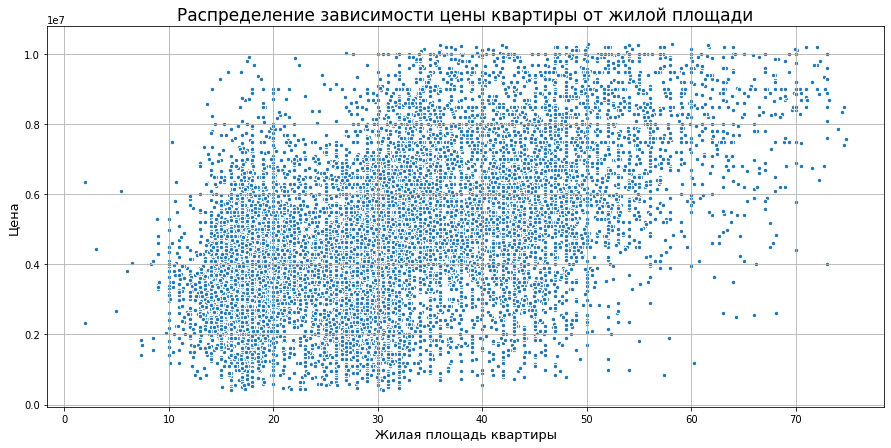

In [87]:
(data
    .plot(
        kind='scatter', 
        x='living_area', 
        y='last_price', 
        grid=True, 
        figsize=(15, 7), 
        style='o', 
        edgecolors='white')
)

plt.title('Распределение зависимости цены квартиры от жилой площади', size=17)
plt.xlabel('Жилая площадь квартиры', size=13)
plt.ylabel('Цена', size=13)

plt.show()
# строим график зависимости стоимости квартиры от ее жилой площади

In [88]:
data['last_price'].corr(data['living_area']) # проверим корреляцию

0.5500883222608203

Связь между жилой площадью и стоимостью есть, но она слабее, нежели с общей площадью квартиры. Это можно объяснить тем, что с увеличением жилой площади растет общая площадь, а соотственно цена, но общая площадь включает в себя еще площадь кухни. Не всем покупателям принципиально иметь бОльшую жилую площадь, так как в случае чего можно сделать перепланировку, но и совсем неважным считать этот параметр нельзя

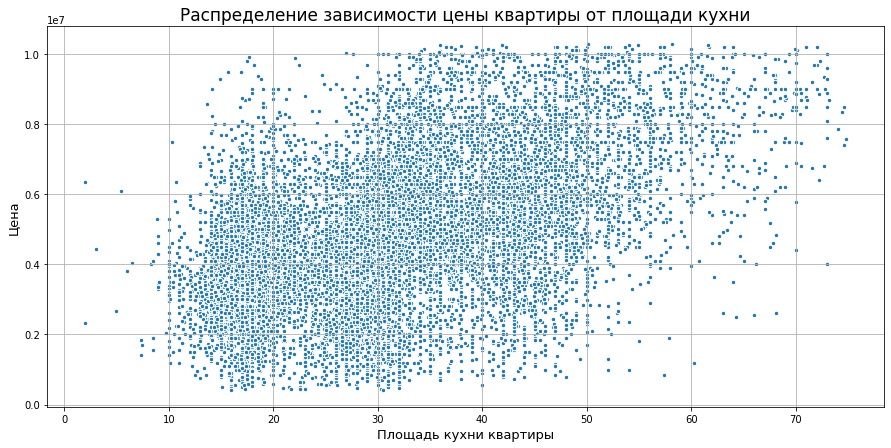

In [89]:
(data
    .plot(
        kind='scatter', 
        x='living_area', 
        y='last_price', 
        grid=True, 
        figsize=(15, 7), 
        style='o', 
        edgecolors='white')
)

plt.title('Распределение зависимости цены квартиры от площади кухни', size=17)
plt.xlabel('Площадь кухни квартиры', size=13)
plt.ylabel('Цена', size=13)

plt.show()

In [90]:
data['last_price'].corr(data['kitchen_area'])

0.47465495396098023

Связь между стоимость и площадью кухни стала еще меньше, ее можно назвать умеренной. Такую связь можно объяснить аналогично тому, что написано выше: покупатели в основном смотрят на общую площадь квартиры и уже сами решают, как ее использовать, поэтому нет смысла ставить цену выше при увеличении площадь кухни.

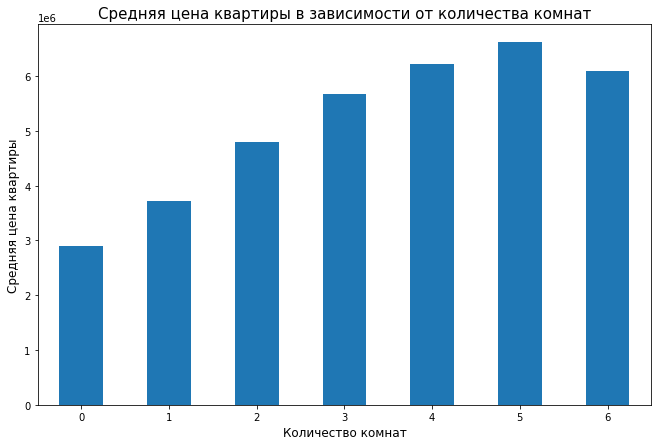

In [91]:
data.groupby('rooms')['last_price'].mean().plot(kind='bar', figsize=(11, 7))

plt.xticks(rotation=0)
plt.title('Средняя цена квартиры в зависимости от количества комнат', size=15)
plt.xlabel('Количество комнат', size=12)
plt.ylabel('Средняя цена квартиры', size=12)

plt.show()

In [92]:
data['last_price'].corr(data['rooms'])

0.4221169556180163

На графике связь практически идеально линейная, однако коэффициент корреляции равен всего 0.422, что говорит не о сильной, а об умеренной связи. 

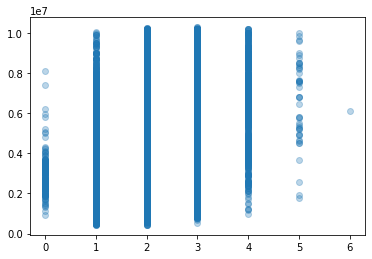

In [93]:
plt.scatter(data['rooms'], data['last_price'], alpha=0.3)

На этом графике видно, что студии стоят дешевле, чем остальные квартиры, но для 2-3-4-хкомнатных квартир размах цен охватывает всю область от 2,5 млн до 20 млн. Здесь опять-таки больше влияет общая площадь и расположение квартиры: 2-хкомнатная квартира может быть больше 4-хкомнатной по площади, а 4-хкомнатная квартира в Санкт-Петербурге будет дороже 4-хкомнатной в Мурино. 

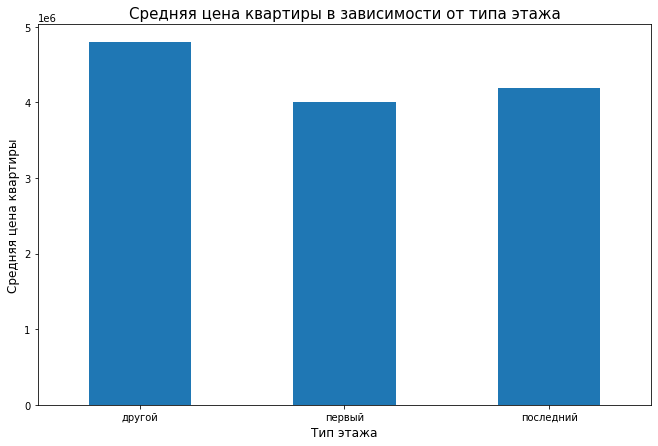

In [94]:
data.groupby('floor_type')['last_price'].mean().plot(kind='bar', figsize=(11, 7))

plt.xticks(rotation=0)
plt.title('Средняя цена квартиры в зависимости от типа этажа', size=15)
plt.xlabel('Тип этажа', size=12)
plt.ylabel('Средняя цена квартиры', size=12)

plt.show()
# построим график зависимости стоимости от типа этажа

<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера:</b>

При ограниченном количестве значений метрик (категориальные и дискретные переменные), таких как количество комнат, категория этажа, а также день, месяц и год размещения объявления, лучше использовать barplot, предварительно рассчитав среднюю цену с группировкой по нужной метрике. Так зависимости будут гораздо нагляднее. Пример написал ниже. </div>

 ✔

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера 2:</b> Отлично, исправлено!👍  </div>

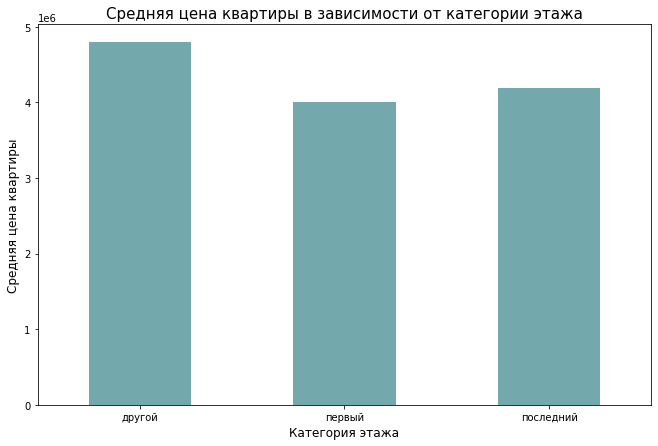

In [95]:
# код ревьюера

data.groupby('floor_type')['last_price'].mean().plot(kind='bar', figsize=(11, 7), color='#73A9AD')

plt.xticks(rotation=0)
plt.title('Средняя цена квартиры в зависимости от категории этажа', size=15)
plt.xlabel('Категория этажа', size=12)
plt.ylabel('Средняя цена квартиры', size=12)

plt.show()

По графику видно, что квартиры на первом этаже стоят значительно дешевле, чем квартиры на не последнем и не первом этаже, квартиры на последнем этаже стоят чуть дороже, чем квартиры на первом этаже, но так же уступают квартирам на "другом" этаже. Это можно объяснить тем, что первый этаж часто не любят из-за близости подвалов, небезопасности и отсутствия вида, последний этаж могут реже выбирать в старых домах без лифта.

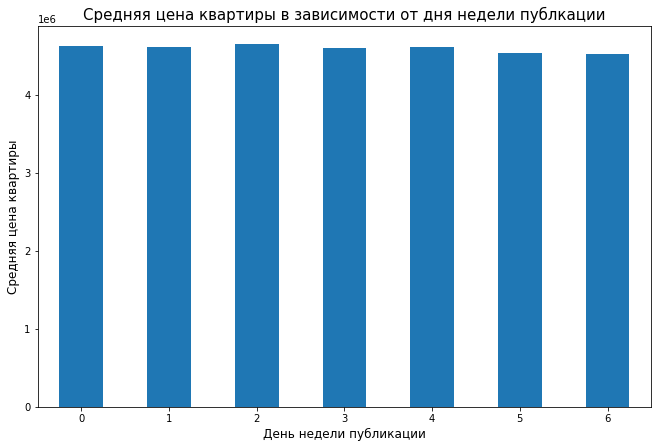

In [96]:
data.groupby('weekday_of_exposition')['last_price'].mean().plot(kind='bar', figsize=(11, 7))

plt.xticks(rotation=0)
plt.title('Средняя цена квартиры в зависимости от дня недели публкации', size=15)
plt.xlabel('День недели публикации', size=12)
plt.ylabel('Средняя цена квартиры', size=12)

plt.show()
# построим график зависимости стоимости от дня недели публикации объявления


На графике barplot видно, что средняя цена квартиры отличается очень незначительно в каждый день недели, значит можно сделать вывод, что стоимость квартиры не зависит от дня недели публикации

In [97]:
data['weekday_of_exposition'].corr(data['last_price'])

-0.012801502428486452

Коэффициент корреляции близок к 0, что говорит об очень слабой связи или ее отсутствии. 

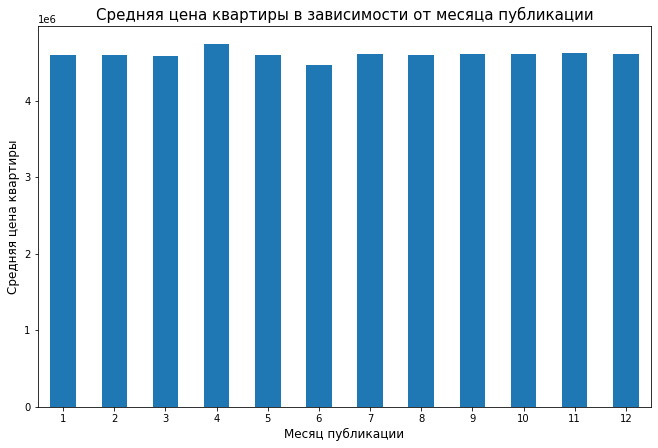

In [98]:
data.groupby('month_of_exposition')['last_price'].mean().plot(kind='bar', figsize=(11, 7))

plt.xticks(rotation=0)
plt.title('Средняя цена квартиры в зависимости от месяца публикации', size=15)
plt.xlabel('Месяц публикации', size=12)
plt.ylabel('Средняя цена квартиры', size=12)

plt.show()
# построим график зависимости стоимости от месяца публикации объявления

In [99]:
data['month_of_exposition'].corr(data['last_price'])

-0.0002965079626391399

В случае с месяцем публикации ситуация аналогична дню недели, от месяца к месяцу средняя цена квартиры меняется очень слабо и коэффициент корреляции в этом случае еще более близок к 0

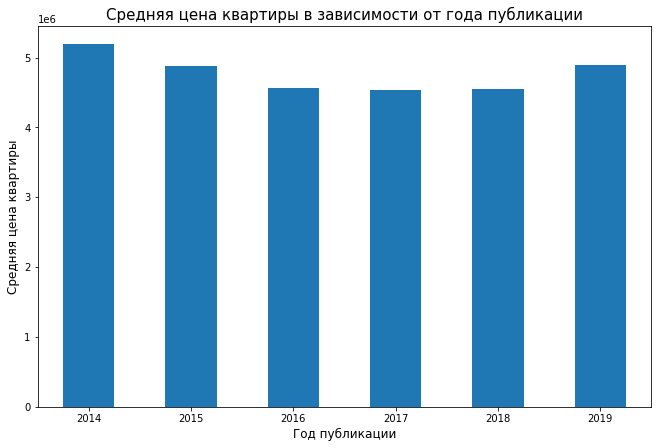

In [100]:
data.groupby('year_of_exposition')['last_price'].mean().plot(kind='bar', figsize=(11, 7))

plt.xticks(rotation=0)
plt.title('Средняя цена квартиры в зависимости от года публикации', size=15)
plt.xlabel('Год публикации', size=12)
plt.ylabel('Средняя цена квартиры', size=12)

plt.show()
# построим график зависимости стоимости от года публикации объявления

In [101]:
data['year_of_exposition'].corr(data['last_price'])

0.01153756488173765

Для рынка недвижимости характерно увеличение цены с каждым последюущим годом, однако на наших графиках получилось, что в 2014 году квартиры стоили дороже, чем в 2019. Скорее всего это связано с тем, что некоторые квартиры с 2014 года до сих пор не проданы как раз из-за высокой цены. Коэффициент корреляции слабо отличается от нуля.

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера:</b> 

Факторы, влияющие(или нет) на стоимость квартиры рассмотрены верно!</div>

### Средняя цена 1 квадратного метра в популярных населенных пунктах

In [102]:
grouped_by_locality = data.pivot_table(index='locality_name', values='price_per_meter', aggfunc=['count', 'mean'])
    
# создадим сводную таблицу grouped_by_locality, сгруппированную по locality_name, в качестве значений возьмем price_per_meter
# в первой колонке с помощью функции count ведется подсчет объявлений для каждого населенного пункта
# во второй с помощью функции mean - средняя цена за 1 кв метр
   

In [103]:
grouped_by_locality.columns = ['count_of_publications', 'mean_price_per_meter']
# переименуем колонки

In [104]:
grouped_by_locality.sort_values(by='count_of_publications', ascending=False).head(10)
# отсортируем данные по убыванию количества публикаций в населенной пункте и выведим первы 10 строк

,count_of_publications,mean_price_per_meter
locality_name,,
Санкт-Петербург,12867,104437.950884
Мурино,581,86233.667435
Кудрово,446,95365.145897
Шушары,431,78673.286543
Всеволожск,382,66683.474031
Колпино,331,75237.833082
Пушкин,323,99755.614365
Парголово,322,90379.294814
Гатчина,300,68545.043467


Самая высокая цена за квадратный метр среди популярных населенных пунктов - в Санкт-Петербурге, самая низкая - в Выборге.

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера:</b> 

Все так</div>

### Зависимость стоимости квартир в Санкт-Петербурге от расстояния до центра города

In [105]:
grouped_by_city_centers_nearest = (data
                                        .query('locality_name == "Санкт-Петербург"')
                                        .pivot_table(index='city_centers_nearest_km', values='last_price'))
# создадим таблицу, которая показывает среднюю стоимость квартиры в Санкт-Петербурге 
# для каждого км удаленности от центра города

In [106]:
grouped_by_city_centers_nearest # распечатаем таблицу

,last_price
city_centers_nearest_km,
0.0,7.141429e+06
1.0,7.565773e+06
2.0,7.357015e+06
3.0,6.711004e+06
4.0,7.053138e+06
5.0,6.959242e+06
6.0,6.656269e+06
7.0,6.219030e+06
8.0,6.101220e+06


In [107]:
# для удобства переведем стоимость квартиры в млн рублей
grouped_by_city_centers_nearest['last_price'] /= 1000000

<AxesSubplot:xlabel='city_centers_nearest_km'>

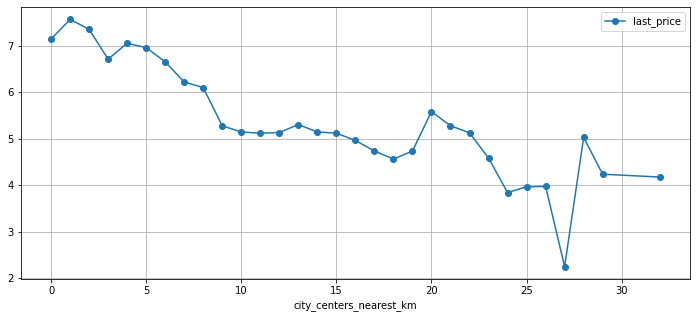

In [108]:
grouped_by_city_centers_nearest.plot(grid=True, figsize=(12, 5), style='o-')
# построим график зависимости цены квартиры в Санкт-Петербурге от удаленности от центра города 

Стоимость квартиры в основном уменьшается с увеличением расстояния до центра

In [109]:
grouped_by_city_centers_nearest = grouped_by_city_centers_nearest.reset_index() 
# сбрасываем индексы, чтобы вывести 'city_centers_nearest_km' в столбец
grouped_by_city_centers_nearest['last_price'].corr(grouped_by_city_centers_nearest['city_centers_nearest_km'])
# считаем корреляцию

-0.8688636177570576

После того, как мы убрали выбросы, график стал более "плавным" и на нем видна обратная зависимость цены и расстояния до центра, коэффициент корреляции отрицательный и очень близок к 1, что подтверждает гипотезу о сильной связи

<div class="alert alert-block alert-success">
<b>✅Комментарий ревьюера:</b> 

Здесь тоже все правильно</div>

## Напишите общий вывод


   В ходе исследовательского анализа данных:
    
    1. Мне удалось заполнить пропуски в колонках ceiling_height, is_apartment, balcony, locality_name, living_area, kitchen_area. В случае с колонках parks_nearest, ponds_nearest, parks_around3000, ponds_around3000, airports_nearest, city_сenters_nearest пропуски находятся в одних и тех строчках, преимущественно за пределами города Санкт-Петербург, в получении этих данных возможен сбой, их следует отправить на доработку
    
    2. Я изменила тип данных в колонках first_day_exposition и balcony на datetime и int соответственно, в дальнейшем это упростила расчеты.
    
    3. Я убрала 59 неявных дубликатов в колонке locality_name.
    
    4. В таблицу добавлены новые столбцы:
     price_per_meter - цена за 1 кв метр
     weekday_of_exposition - день недели публикации объявления
     month_of_exposition - номер месяца публикации объявления
     year_of_exposition - год публикации объявления
     floor_type - тип этажа (первый, последний, другой)
     city_centers_nearest_km - расстояние до центра города в километрах
     
    5. Построены гистограммы распределения следующих параметров:
        общая площадь;
        жилая площадь;
        площадь кухни;
        цена объекта;
        количество комнат;
        высота потолков;
        тип этажа квартиры («первый», «последний», «другой»);
        общее количество этажей в доме;
        расстояние до центра города в метрах;
        расстояние до ближайшего парка
        Обработаны аномальные значения с помощью них
        
    6. Посчитана средняя продолжительность продажи квартиры и она равна 90 дней. Все продажи, которые заняли меньше 43 дней, можно считать очень быстрыми. Продажи, которые заняли более 216 дней - необычайно долгими.
     
    7. Изучена зависимость стоимости квартиры от различных показателей, посчитать коэффициенты корреляции, построить графики по сводным таблицам.
    Результаты анализа следующие:
     - связь между общей площадью и стоимостью квартиры - заметная, коэффициент корреляции равен 0.66
     - связи между жилой площадью и стоимостью квартиры немного меньше, коэффициент корреляциия равен 0.54
     - связь между площадью кухни и стоимостью квартиры умеренная, коэффициент корреляции равен 0.47
     - связь между количеством комнат и стоимостью квартиры умеренна, коэффициент корреляции равен 0.42
     - связь между типом этажа имеется, однако посчитать корреляцию невозможно, так как колонка floors_type имеет тип данных object, однако по графику видно, что квартиры на первом этаже стоят дешевле всех, квартиры на последнем этаже стоят чуть дешевле квартир на "другом этаже"
     - связь между днем недели публикации и стоимостью квартиры низкая, коэффициент корреляции - -0.014
     - связь месяцем публикации и стоимостью квартиры еще ниже, коэфиициент корреляции - 0.0008
     - связь между годом публикации и стоимостью квартиры чуть больше и отрицательная, коэффициент корреляции - 0.01
     
     Нужно учитывать, что в расчетах использовался коэффициент Пирсона и его близость к 0 может означать не только отсутствие связи между величинами, но и наличие более сложной связи (нелинейной).
     
     8. Я посчитала среднюю стоимость за квадратный метр в 10 самых популярных локациях: дороже всего 1 квадратный метр стоит в Санкт-Петербурге, дешевле всего - в Выборге.
     
     9. Изучила взаимосвязь стоимости квартиры в Санкт-Петербурге и удаленности от центра, после удаления аномальных данных(выбросов) коэффициент корреляции получился равен -0.88 - это значит, что зависимость очень сильная. Чем дальше квартира находится от центра, тем дешевле она будет стоить.
    
    10. Среднестатистическая двухкомнатная квартира из нашего исследования находится в Санкт-Петербурге, имеет общую площадь 54 кв.м (жилая 29 кв.м, кухня 9 кв.м), потолки 2,7 м, расположена на шестом этаже с одним балконом, продаётся за 4,6 млн руб., находится в 15 км от центра и в 30 км от аэропорта, рядом с одним парком (486 м) и одним прудом (535 м), а объявление размещено в среду–четверг июня 2017 года.
    
    
    
    
    
    
    
    
    
    
    

<div class="alert alert-block alert-warning">
<b>🔁Комментарий ревьюера:</b> 
    
Можно дополнительно описать основные характеристики "среднестатистической" квартиры из объявления. 
    
    
**Хочу обратить твое внимание на то, что после исправления замечаний в некоторых пунктах исследования могут измениться результаты, поэтому нужно будет подкорректировать выводы.**
</div>

**Чек-лист готовности проекта**

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Файл с данными открыт.
- [x]  Файл с данными изучен: выведены первые строки, использован метод `info()`, построены гистограммы.
- [x]  Найдены пропущенные значения.
- [x]  Пропущенные значения заполнены там, где это возможно.
- [x]  Объяснено, какие пропущенные значения обнаружены.
- [x]  В каждом столбце установлен корректный тип данных.
- [x]  Объяснено, в каких столбцах изменён тип данных и почему.
- [x]  Устранены неявные дубликаты в названиях населённых пунктов.
- [x]  Обработаны редкие и выбивающиеся значения (аномалии).
- [x]  В таблицу добавлены новые параметры:
       – цена одного квадратного метра;
       – день публикации объявления (0 - понедельник, 1 - вторник и т. д.);
       – месяц публикации объявления;
       – год публикации объявления;
       – тип этажа квартиры (значения — «первый», «последний», «другой»);
       – расстояние до центра города в километрах.
- [x]  Изучены и описаны параметры:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - цена объекта;
        - количество комнат;
        - высота потолков;
        - тип этажа квартиры («первый», «последний», «другой»);
        - общее количество этажей в доме;
        - расстояние до центра города в метрах;
        - расстояние до ближайшего парка.
- [x]  Выполнено задание «Изучите, как быстро продавались квартиры (столбец `days_exposition`)»:
    - построена гистограмма;
    - рассчитаны среднее и медиана;
    - описано, сколько обычно занимает продажа и указано, какие продажи можно считать быстрыми, а какие — необычно долгими.
- [x]  Выполнено задание «Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта». Построены графики, которые показывают зависимость цены от параметров:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - количество комнат;
        - тип этажа, на котором расположена квартира (первый, последний, другой);
        - дата размещения (день недели, месяц, год).
- [x]  Выполнено задание «Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений»:
    - выделены населённые пункты с самой высокой и низкой стоимостью квадратного метра.
- [x]  Выполнено задание «Выделите квартиры в Санкт-Петербурге с помощью столбца `locality_name` и вычислите их среднюю стоимость на разном удалении от центра»:
    -  учтён каждый километр расстояния, известны средние цены квартир в одном километре от центра, в двух и так далее;
    -  описано, как стоимость объекта зависит от расстояния до центра города;
    -  построен график изменения средней цены для каждого километра от центра Петербурга.
- [x]  На каждом этапе сделаны промежуточные выводы.
- [x]  В конце проекта сделан общий вывод.